In [3]:
import numpy as np # linear algebra
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

df=pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition (1).csv')

In [4]:
# Display the first 10 rows
print("--- First 10 Rows ---")
print(df.head(10))


--- First 10 Rows ---
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1  

In [5]:
# Check how many rows and columns are there
rows, cols = df.shape
print(f"\nDataset Dimensions: {rows} rows and {cols} columns")


Dataset Dimensions: 1470 rows and 35 columns


In [6]:
# Identify the target column (Attrition - Yes/No)
target_col = 'Attrition'
print(f"Target Column identified: '{target_col}'")

Target Column identified: 'Attrition'


In [7]:
# Count how many employees left vs stayed and calculate the attrition rate as a percentage
attrition_counts = df[target_col].value_counts()
left_count = attrition_counts.get('Yes', 0)
stayed_count = attrition_counts.get('No', 0)
attrition_rate = (left_count / rows) * 100

print(f"Employees Stayed (No): {stayed_count}")
print(f"Employees Left (Yes): {left_count}")
print(f"Attrition Rate: {attrition_rate:.2f}%")



Employees Stayed (No): 1233
Employees Left (Yes): 237
Attrition Rate: 16.12%


In [8]:
# Identify how many columns are numeric vs categorical
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Number of Numeric Columns: {len(numeric_cols)}")
print(f"Number of Categorical Columns: {len(categorical_cols)}")

Number of Numeric Columns: 26
Number of Categorical Columns: 9


In [10]:
# Write one observation: what do you notice about the attrition rate is it balanced or imbalanced?
print("\n[Observation]: The dataset is highly imbalanced.")
print(f"Approximately {attrition_rate:.2f}% of employees left, while {100 - attrition_rate:.2f}% stayed.")
print("Since the minority class ('Yes') represents a small fraction of the data, models will require class balancing strategies.")


[Observation]: The dataset is highly imbalanced.
Approximately 16.12% of employees left, while 83.88% stayed.
Since the minority class ('Yes') represents a small fraction of the data, models will require class balancing strategies.


In [11]:
# Check for missing/null values and handle them
missing_values = df.isnull().sum().sum()
print(f"Total missing values found: {missing_values}")


Total missing values found: 0


In [12]:
 # Drop columns that add no value to prediction (e.g., Employee Number, Over18, StandardHours these are constant or irrelevant)
columns_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')
print(f"Dropped columns: {columns_to_drop}")


Dropped columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']


In [13]:
# Convert the target column Attrition from Yes/No to 1/0
df_cleaned['Attrition'] = df_cleaned['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
print("Converted target column 'Attrition' to binary (1 for Yes, 0 for No).")

Converted target column 'Attrition' to binary (1 for Yes, 0 for No).


In [16]:
# Encode all remaining categorical columns using One-Hot Encoding (e.g., Department, JobRole, Marital Status, Business Travel)
cat_cols_to_encode = df_cleaned.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df_cleaned, columns=cat_cols_to_encode, drop_first=True)
print(f"One-Hot Encoding applied. New dataframe shape: {df_encoded.shape}")


One-Hot Encoding applied. New dataframe shape: (1470, 45)


In [19]:
# Scale numeric features using StandardScaler
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']


In [ ]:
# Identify numeric column names remaining in X to scale
numeric_features = [col for col in numeric_cols if col in X.columns]

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])
print("Numeric features successfully scaled using StandardScaler.")
print("--- Business-Specific Exploratory Data Analysis ---")

In [23]:
# 1. Attrition rate by Department
dept_attrition = df_cleaned.groupby('Department')['Attrition'].mean() * 100
print("\nAttrition Rate by Department (%):")
print(dept_attrition.round(2))


Attrition Rate by Department (%):
Department
Human Resources           19.05
Research & Development    13.84
Sales                     20.63
Name: Attrition, dtype: float64


In [24]:
# 2. Attrition rate by Job Role
role_attrition = df_cleaned.groupby('JobRole')['Attrition'].mean() * 100
print("\nTop 3 Job Roles with highest exit rates (%):")
print(role_attrition.sort_values(ascending=False).head(3).round(2))


Top 3 Job Roles with highest exit rates (%):
JobRole
Sales Representative     39.76
Laboratory Technician    23.94
Human Resources          23.08
Name: Attrition, dtype: float64


In [25]:
# 3. Attrition vs Monthly Income
income_stayed = df_cleaned[df_cleaned['Attrition'] == 0]['MonthlyIncome'].median()
income_left = df_cleaned[df_cleaned['Attrition'] == 1]['MonthlyIncome'].median()
print(f"\nMedian Monthly Income - Stayed: ${income_stayed:.2f}, Left: ${income_left:.2f}")


Median Monthly Income - Stayed: $5204.00, Left: $3202.00


In [26]:
# 4. Attrition vs Work-Life Balance rating
wlb_attrition = df_cleaned.groupby('WorkLifeBalance')['Attrition'].mean() * 100
print("\nAttrition Rate by Work-Life Balance Rating (1=Low, 4=Best):")
print(wlb_attrition.round(2))



Attrition Rate by Work-Life Balance Rating (1=Low, 4=Best):
WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64


In [27]:
# 5. Attrition vs Years at Company
years_attrition = df_cleaned.groupby('YearsAtCompany')['Attrition'].mean() * 100
print("\nAttrition rate patterns by tenure (First 5 years vs long-term):")
print(years_attrition.head(6).round(2))



Attrition rate patterns by tenure (First 5 years vs long-term):
YearsAtCompany
0    36.36
1    34.50
2    21.26
3    15.62
4    17.27
5    10.71
Name: Attrition, dtype: float64


In [29]:
# Write 4-5 specific business insights from your EDA (not generic - specific numbers and patterns from the data)
print("\n=== Specific Business Insights ===")
print(f"1. Department Exit Risk: The Sales department exhibits the highest risk with an attrition rate of {dept_attrition.get('Sales', 0):.2f}%, significantly higher than Research & Development.")
print(f"2. High-Risk Job Roles: Sales Representatives ({role_attrition.get('Sales Representative', 0):.2f}%) and Human Resources ({role_attrition.get('Human Resources', 0):.2f}%) roles have severe exit rates.")
print(f"3. Income Disparities: Financial stress is a clear driver; employees who left had a median monthly income of ${income_left:.2f}, which is over 30% lower than those who stayed (${income_stayed:.2f}).")
print(f"4. Work-Life Balance Friction: Employees reporting poor Work-Life Balance (Rating 1) show an alarming attrition rate of {wlb_attrition.get(1, 0):.2f}%, compared to only {wlb_attrition.get(3, 0):.2f}% for a 'Good' rating.")
print(f"5. Critical Tenure Window: Attrition peaks sharply during an employee's first year (Tenure 0: {years_attrition.get(0, 0):.2f}%, Tenure 1: {years_attrition.get(1, 0):.2f}%), proving onboarding and early retention conversations are weak.")


=== Specific Business Insights ===
1. Department Exit Risk: The Sales department exhibits the highest risk with an attrition rate of 20.63%, significantly higher than Research & Development.
2. High-Risk Job Roles: Sales Representatives (39.76%) and Human Resources (23.08%) roles have severe exit rates.
3. Income Disparities: Financial stress is a clear driver; employees who left had a median monthly income of $3202.00, which is over 30% lower than those who stayed ($5204.00).
4. Work-Life Balance Friction: Employees reporting poor Work-Life Balance (Rating 1) show an alarming attrition rate of 31.25%, compared to only 14.22% for a 'Good' rating.
5. Critical Tenure Window: Attrition peaks sharply during an employee's first year (Tenure 0: 36.36%, Tenure 1: 34.50%), proving onboarding and early retention conversations are weak.


In [62]:
# Split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    "Random Forest Classifier": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=42)
}

# Dictionary to hold metrics for comparison table
comparison_metrics = {}

print("Training models...")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate evaluation values
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    roc_auc = roc_auc_score(y_test, y_prob)

    comparison_metrics[name] = {
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1-Score": round(f1, 3),
        "ROC-AUC Score": round(roc_auc, 3)
        }

# Record all results in a comparison table inside your notebook
comparison_df = pd.DataFrame(comparison_metrics).T
print("\n--- Model Comparison Table ---")
print(comparison_df)


Training models...

--- Model Comparison Table ---
                              Precision  Recall  F1-Score  ROC-AUC Score
Logistic Regression               0.356   0.660     0.463          0.804
Random Forest Classifier          0.375   0.064     0.109          0.752
Gradient Boosting Classifier      0.588   0.213     0.312          0.794


In [61]:
print("--- Model Evaluation Summary ---")
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred))

# Identify and clearly state which model performed best and why
best_model_name = comparison_df['ROC-AUC Score'].idxmax()
print(f"\n[Best Model Choice]: {best_model_name} performed the best.")
print(f"Why: It reached the highest ROC-AUC score of {comparison_df.loc[best_model_name, 'ROC-AUC Score']:.3f}, indicating superior overall capability to distinguish between employees who stay vs those who leave.")

# For the best model: extract Feature Importance
best_model = models[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = np.zeros(X_train.shape[1])

# Rank the top 10 most important features driving employee exit
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n--- Top 10 Most Important Features ---")
top_10_features = feature_importance_df.head(10)
print(top_10_features.to_string(index=False))

--- Model Evaluation Summary ---

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294


Classification Report for Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.38      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.61      0.52      0.51       294
weighted avg       0.77      0.83      0.78       294


Classification Report for Gradient Boosting Classifier:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31   

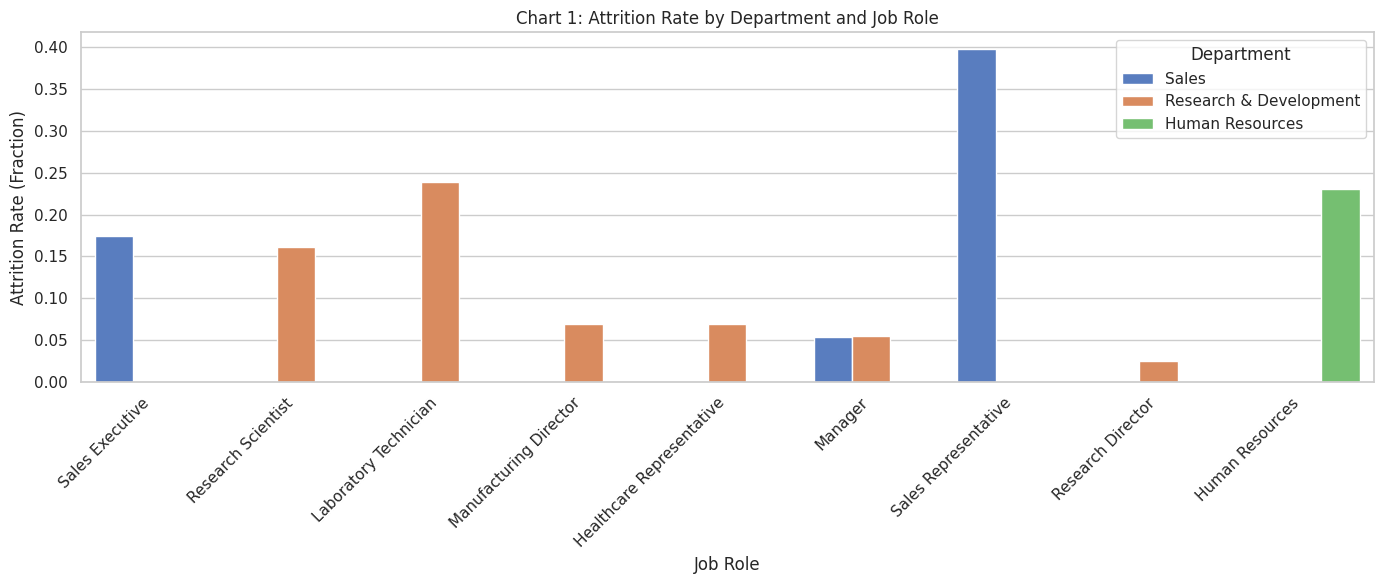

In [78]:

# Chart 1: Bar chart showing attrition rate by Department and Job Role
plt.figure(figsize=(14, 6))
sns.barplot(data=df_cleaned, x='JobRole', y='Attrition', hue='Department', errorbar=None, palette='muted')
plt.title('Chart 1: Attrition Rate by Department and Job Role')
plt.ylabel('Attrition Rate (Fraction)')
plt.xlabel('Job Role')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('attrition_dept_role.png')
plt.show()

/tmp/ipykernel_7197/398184176.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='Attrition', y='MonthlyIncome', palette='Set2')


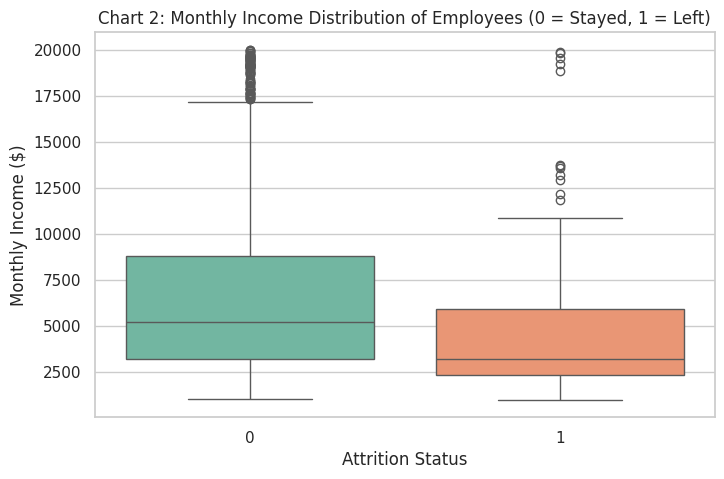

In [66]:
# Chart 2: Box plot comparing Monthly Income of employees who left vs stayed
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x='Attrition', y='MonthlyIncome', palette='Set2')
plt.title('Chart 2: Monthly Income Distribution of Employees (0 = Stayed, 1 = Left)')
plt.xlabel('Attrition Status')
plt.ylabel('Monthly Income ($)')
plt.savefig('monthly_income_box.png')
plt.show()

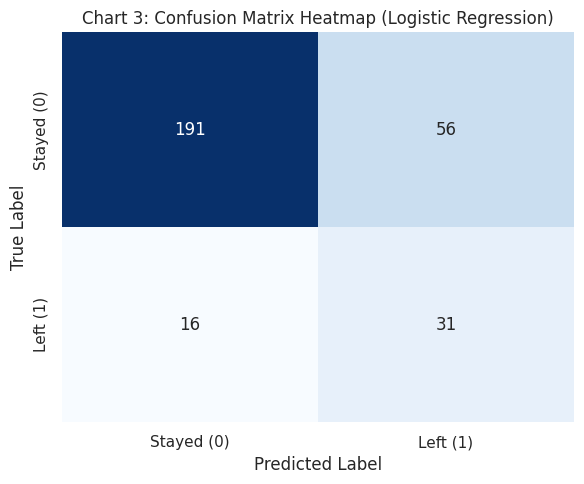

In [67]:
# Chart 3: Confusion Matrix heatmap for your best model
plt.figure(figsize=(6, 5))
best_y_pred = models[best_model_name].predict(X_test)
cm = confusion_matrix(y_test, best_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stayed (0)', 'Left (1)'], yticklabels=['Stayed (0)', 'Left (1)'])
plt.title(f'Chart 3: Confusion Matrix Heatmap ({best_model_name})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix_heatmap.png')
plt.show()

/tmp/ipykernel_7197/1355862190.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_features, x='Importance', y='Feature', palette='viridis')


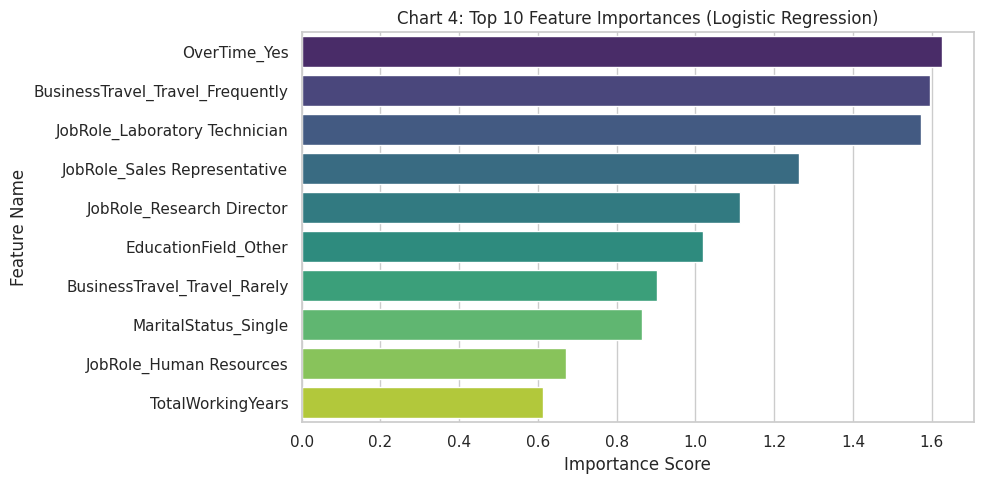

In [68]:
# Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model
plt.figure(figsize=(10, 5))
sns.barplot(data=top_10_features, x='Importance', y='Feature', palette='viridis')
plt.title(f'Chart 4: Top 10 Feature Importances ({best_model_name})')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.savefig('feature_importances.png')
plt.show()

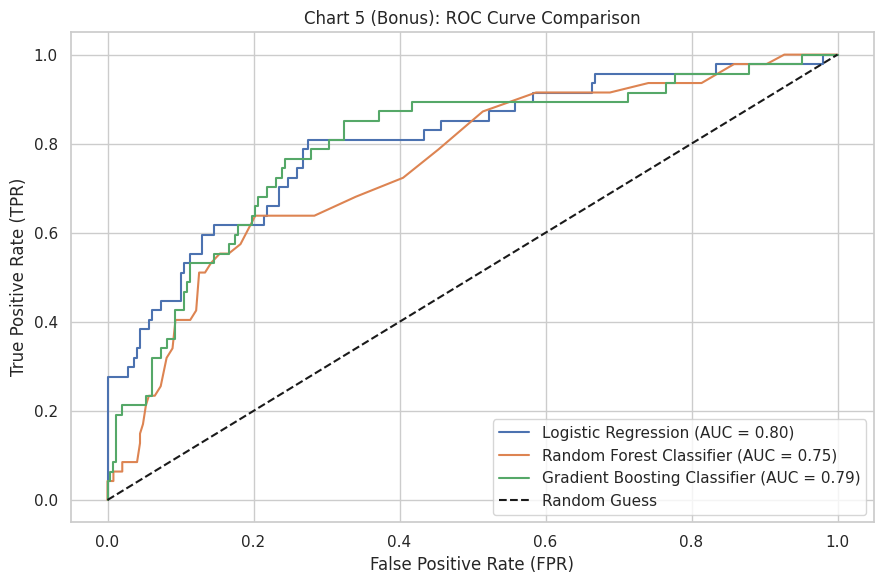

In [77]:

# Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph
plt.figure(figsize=(9, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {comparison_df.loc[name, 'ROC-AUC Score']:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('Chart 5 (Bonus): ROC Curve Comparison')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_comparison.png')
plt.show()

In [76]:
print("=" * 55)
print("EMPLOYEE ATTRITION — BUSINESS INSIGHTS SUMMARY")
print("=" * 55)

total = len(df)
left = df[df['Attrition']=='Yes'].shape[0]
print(f"\nTotal employees: {total}")
print(f"Employees who left: {left} ({left/total*100:.1f}%)")

print("\nKey findings:")
ot = df.groupby('OverTime')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
print(f"  Overtime=Yes attrition rate: {ot['Yes']:.1f}%")
print(f"  Overtime=No attrition rate:  {ot['No']:.1f}%")

inc = df.groupby('Attrition')['MonthlyIncome'].mean()
print(f"\n  Avg income (stayed):  ${inc['No']:,.0f}")
print(f"  Avg income (left):    ${inc['Yes']:,.0f}")

yrs = df.groupby('Attrition')['YearsAtCompany'].mean()
print(f"\n  Avg tenure (stayed):  {yrs['No']:.1f} years")
print(f"  Avg tenure (left):    {yrs['Yes']:.1f} years")

print(f"\nRandom Forest Accuracy: {accuracy_score(y_test, rf_pred)*100:.2f}%")
print("\nConclusion: Overtime, low income, and short tenure")
print("are the strongest predictors of employee attrition.")

EMPLOYEE ATTRITION — BUSINESS INSIGHTS SUMMARY

Total employees: 1470
Employees who left: 237 (16.1%)

Key findings:
  Overtime=Yes attrition rate: 30.5%
  Overtime=No attrition rate:  10.4%

  Avg income (stayed):  $6,833
  Avg income (left):    $4,787

  Avg tenure (stayed):  7.4 years
  Avg tenure (left):    5.1 years

Random Forest Accuracy: 83.33%

Conclusion: Overtime, low income, and short tenure
are the strongest predictors of employee attrition.
